# 2.5. Automatic Differentiation

We mentioned in the last chapter that calculus is the foundation of deep learning. In particular, the chain rule can be applied in a purely mechanical manner in a process known as automatic differentiation, or _autograd_. Let's get started!

In [1]:
import mindspore
mindspore.set_device(device_target='Ascend', device_id=0)

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:146: SyntaxWarning: invalid escape sequence '\c'
  2. In forward, tiling would not split c1 and c0, find c1\c0 based on t2.
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/unify_schedule/vector/transdata/common/graph/transdata_graph_info.py:172: SyntaxWarning: invalid escape sequence '\c'
  1. Forward: tiling would not split c1\c0\h0, find c1\c0\h1\h0 based on t2
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangepiaipro-20t/lib/python3.12/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/home/HwHiAiUser/.pyenv/versions/3.12.13/envs/orangep

## 2.5.1. A Simple Function

Consider the function $y = 2\mathbf{x}^{\mathsf{T}}\mathbf{x}$. $\mathbf{x}$ is a column vector of size 4.

In [2]:
import mindspore.ops as ops
x = ops.arange(4)
x

/usr/local/Ascend/cann-8.5.0/python/site-packages/asc_op_compile_base/asc_op_compiler/ascendc_compile_gen_code.py:161: SyntaxWarning: invalid escape sequence '\w'
  match = re.search(f'{option}=(\w+)', ' '.join(compile_options))
2026-03-25 22:57:58.566751: E external/org_tensorflow/tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute is_closed which is not in the op definition: Op<name=Range; signature=start:Tidx, limit:Tidx, delta:Tidx -> output:Tidx; attr=Tidx:type,default=DT_INT32,allowed=[DT_BFLOAT16, DT_HALF, DT_FLOAT, DT_DOUBLE, DT_INT8, DT_INT16, DT_INT32, DT_INT64, DT_UINT16, DT_UINT32]> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node Range1}}


Tensor(shape=[4], dtype=Int64, value= [0, 1, 2, 3])

Let's define our function $y$ in terms of $\mathbf{x}$.

In [3]:
def forward(x):
    return 2 * ops.vecdot(x, x)

y = forward(x)
y

Tensor(shape=[], dtype=Int64, value= 28)

Compute the gradient of our function $y$ at $\mathbf{x}$.

In [4]:
from mindspore import grad
x_grad = grad(forward)(x)
x_grad

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result


Tensor(shape=[4], dtype=Int64, value= [ 0,  4,  8, 12])

Let's confirm that the derivative of $y$ with respect to vector $\mathbf{x}$ is indeed $4\mathbf{x}$ as expected.

In [5]:
ops.all(x_grad == 4 * x).item()

True

Let's calculate the gradient of another function.

In [6]:
def forward(x):
    return x.sum()

x_grad = grad(forward)(x)
x_grad

Tensor(shape=[4], dtype=Int64, value= [1, 1, 1, 1])

## 2.5.2. Backward for Non-Scalar Variables

More often, we have vector-valued functions taking a vector $\mathbf{x}$ and returning another vector $\mathbf{y}$. In such cases, the gradient function of $\mathbf{y}$ is not a vector but a type of matrix known as the _Jacobian matrix_.

In the field of deep learning, we are not particularly interested in the Jacobian matrix itself, but rather the sum of gradients of each component of $\mathbf{y}$, resulting in a vector the same shape as $\mathbf{x}$.

Consider a column vector $\mathbf{x}$ with 4 elements and $\mathbf{y}$ defined as the Hadamard product of $\mathbf{x}$ and itself. Then $\mathbf{y}$ is itself a column vector with 4 elements and its gradient a Jacobian matrix. Instead of computing the Jacobian matrix directly, we sum the gradients of each element of $\mathbf{y}$ to yield a vector the same shape as $\mathbf{x}$.

In [7]:
def forward(x):
    return x * x

x_grad = grad(forward)(x)
x_grad

Tensor(shape=[4], dtype=Int64, value= [0, 2, 4, 6])

## 2.5.3. Detaching Computation

Sometimes, we want to create intermediate terms or variables which we do not want to compute the gradient of. In this case, we need to _detach_ the computational graph of the intermediate term from the result.

For example, we might have `y = x * x` and `z = y * x` but we want to treat `y` opaquely. MindSpore allows us to create a new variable `u = y` where the details of how `u` was constructed are forgotten, via the `ops.stop_gradient` method. Then we have `z = u * x` and the gradient of `z` with respect to `x` is `u`, instead of the `3 * x * x` we expect if we "remembered" that `u = x * x` and therefore `z = x * x * x`. 

In [8]:
def forward(x):
    y = x * x
    u = ops.stop_gradient(y)
    z = u * x
    return z, u

z, u = forward(x)
x_grad = grad(forward)(x)
ops.all(x_grad == u).item()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result


True

Since we retained the computational graph of `y`, we can still calculate its gradient with respect to `x`.

In [9]:
def forward(x):
    y = x * x
    return y.sum()

x_grad = grad(forward)(x)
ops.all(x_grad == 2 * x).item()

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result


True

## 2.5.4. Gradients and Python Control Flow

More interestingly in deep learning, it is common to encounter functions making extensive use of Python control flow such as `if` / `else` statements and `while` loops which cannot be cleanly expressed as a simple mathematical formula. We still need to compute the gradients of such functions, which _autograd_ handles normally as with any other function.

In [10]:
def f(a):
    b = a * 2
    while ops.norm(b, dim=0) < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

Let's initialize a random-valued variable `a` and compute `d = f(a)`. Since the value of `a` is random, we cannot predict the computational graph in advance - which branch of the `if` / `else` it will take or how many times it will execute the body of the `while` loop. Nevertheless, given a concrete value `a`, we can apply backpropagation and compute the gradient at point `a` through _autograd_.

In [11]:
a = ops.randn(())
a

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result


Tensor(shape=[], dtype=Float32, value= -0.462204)

In [12]:
d = f(a)
d

/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: SyntaxWarning: invalid escape sequence '\B'
  Return BN\BH SCH Result
/usr/local/Ascend/cann-8.5.0/python/site-packages/tbe/dsl/classifier/transdata/transdata_classifier.py:223: Sy

Tensor(shape=[], dtype=Float32, value= -189319)

In [13]:
a_grad = grad(f)(a)
a_grad

Tensor(shape=[], dtype=Float32, value= 409600)

The function `f` above is a bit contrived. However, simply put, it is a piecewise defined linear function of its input `a`. As such, we can expect `f(a) / a` to be a vector of constant entries and match the gradient of `f` with respect to `a`.

In [14]:
(a_grad == d / a).item()

True

## 2.5.5. Discussion

This covers the basics of automatic differentiation, also known as _autograd_, required for us to get started with machine learning.

## 2.5.6. Exercises

Let's plot a graph of $y = \sin{x}$ and its derivative using _autograd_. We'll skip the remaining exercises since they're mostly written textbook questions or purely exploratory.

In [15]:
x = ops.arange(0, 10, 0.1)
x

Tensor(shape=[100], dtype=Float32, value= [ 0.00000000e+00,  1.00000001e-01,  2.00000003e-01,  3.00000012e-01,  4.00000006e-01,  5.00000000e-01,  6.00000024e-01,  6.99999988e-01,  8.00000012e-01,  9.00000036e-01,  1.00000000e+00,  1.10000002e+00, 
  1.20000005e+00,  1.30000007e+00,  1.39999998e+00,  1.50000000e+00,  1.60000002e+00,  1.70000005e+00,  1.80000007e+00,  1.89999998e+00,  2.00000000e+00,  2.10000014e+00,  2.20000005e+00,  2.29999995e+00, 
  2.40000010e+00,  2.50000000e+00,  2.60000014e+00,  2.70000005e+00,  2.79999995e+00,  2.90000010e+00,  3.00000000e+00,  3.10000014e+00,  3.20000005e+00,  3.29999995e+00,  3.40000010e+00,  3.50000000e+00, 
  3.60000014e+00,  3.70000005e+00,  3.79999995e+00,  3.90000010e+00,  4.00000000e+00,  4.09999990e+00,  4.20000029e+00,  4.30000019e+00,  4.40000010e+00,  4.50000000e+00,  4.59999990e+00,  4.70000029e+00, 
  4.80000019e+00,  4.90000010e+00,  5.00000000e+00,  5.09999990e+00,  5.20000029e+00,  5.30000019e+00,  5.40000010e+00,  5.50000000e+0

In [16]:
def forward(x):
    return ops.sin(x)

y = forward(x)
y

Tensor(shape=[100], dtype=Float32, value= [ 0.00000000e+00,  9.98334214e-02,  1.98669329e-01,  2.95520216e-01,  3.89418334e-01,  4.79425550e-01,  5.64642489e-01,  6.44217670e-01,  7.17356145e-01,  7.83326924e-01,  8.41470957e-01,  8.91207397e-01, 
  9.32039142e-01,  9.63558257e-01,  9.85449791e-01,  9.97494936e-01,  9.99573529e-01,  9.91664767e-01,  9.73847628e-01,  9.46300089e-01,  9.09297407e-01,  8.63209307e-01,  8.08496356e-01,  7.45705247e-01, 
  6.75463140e-01,  5.98472178e-01,  5.15501261e-01,  4.27379847e-01,  3.34988207e-01,  2.39249244e-01,  1.41120017e-01,  4.15805206e-02, -5.83741888e-02, -1.57745644e-01, -2.55541205e-01, -3.50783229e-01, 
 -4.42520559e-01, -5.29836178e-01, -6.11857831e-01, -6.87766194e-01, -7.56802440e-01, -8.18277061e-01, -8.71575892e-01, -9.16166008e-01, -9.51602101e-01, -9.77530122e-01, -9.93691027e-01, -9.99923229e-01, 
 -9.96164620e-01, -9.82452631e-01, -9.58924294e-01, -9.25814748e-01, -8.83454561e-01, -8.32267284e-01, -7.72764444e-01, -7.05540299e-0

In [17]:
x_grad = grad(forward)(x)
x_grad

Tensor(shape=[100], dtype=Float32, value= [ 1.00000000e+00,  9.95004177e-01,  9.80066538e-01,  9.55336511e-01,  9.21060860e-01,  8.77582550e-01,  8.25335681e-01,  7.64842153e-01,  6.96706772e-01,  6.21609926e-01,  5.40302336e-01,  4.53596175e-01, 
  3.62357706e-01,  2.67498732e-01,  1.69967175e-01,  7.07372054e-02, -2.91995462e-02, -1.28844544e-01, -2.27202177e-01, -3.23289543e-01, -4.16146845e-01, -5.04846215e-01, -5.88501155e-01, -6.66275978e-01, 
 -7.37393737e-01, -8.01143527e-01, -8.56888890e-01, -9.04072165e-01, -9.42222357e-01, -9.70958173e-01, -9.89992499e-01, -9.99135137e-01, -9.98294771e-01, -9.87479806e-01, -9.66798186e-01, -9.36456740e-01, 
 -8.96758318e-01, -8.48100007e-01, -7.90967762e-01, -7.25932240e-01, -6.53643608e-01, -5.74824035e-01, -4.90260601e-01, -4.00799006e-01, -3.07332754e-01, -2.10795790e-01, -1.12152629e-01, -1.23883775e-02, 
  8.74991640e-02,  1.86512470e-01,  2.83662200e-01,  3.77977669e-01,  4.68516946e-01,  5.54374456e-01,  6.34692967e-01,  7.08669782e-0

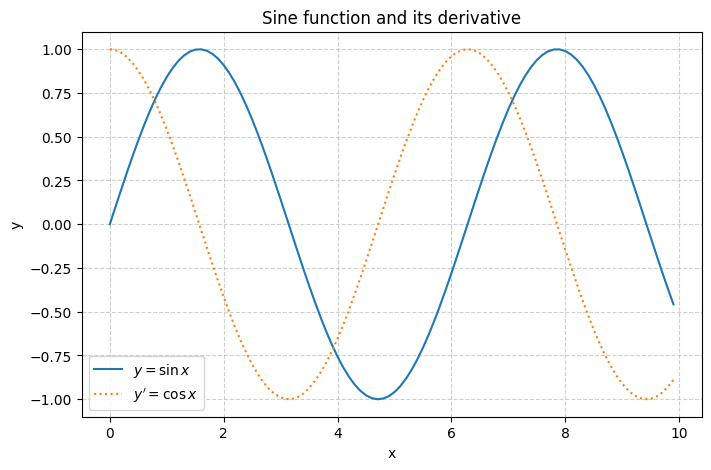

In [18]:
import matplotlib.pyplot as plt

# 1. Convert tensors to Numpy arrays
x_np = x.asnumpy()
y_np = y.asnumpy()
x_grad_np = x_grad.asnumpy()

# 2. Set the graph to be plotted
plt.figure(figsize=(8, 5))

# 3. Plot our function y = sin(x) on the graph
plt.plot(x_np, y_np, label='$y = \\sin{x}$', linestyle='-')

# 4. Plot our gradient function y' = cos(x) on the graph
plt.plot(x_np, x_grad_np, label='$y\' = \\cos{x}$', linestyle=':')

# 5. Add a title, label the axes and include a coordinate grid and legend
plt.title('Sine function and its derivative')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# 6. Display the graph
plt.show()